In [1]:
import cv2
from PIL import Image
import os
import numpy as np
import pyheif
import matplotlib.pyplot as plt

In [ ]:
class ImgToDocu:
    A4 = (1.414, 1)
    def __init__(self,img_path,save_path=None):
        self.img_path = img_path
        self.save_path = save_path
        self.img = self.read_img()
        self.spreaded = None
    
    def read_img(self):
        """
        이미지 불러오기
        """
        img_type = os.path.splitext(self.img_path)[-1]
        if img_type=='.HEIC':
            print('this image is HEIC!')
            heif_file = pyheif.read(self.img_path)
            img = Image.frombytes(
            heif_file.mode,
            heif_file.size,
            heif_file.data,
            "raw",
            heif_file.mode,
            heif_file.stride,
            )
            img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
        elif img_type=='.jpg' or img_type=='.png':
            img = cv2.imread(self.img_path)
        else:
            raise Exception('처리할 수 없는 확장자 입니다.')
        return img

    def imshow(self,img):
        if len(np.array(img).shape) == 3:
            cn = np.array(img).shape[-1]
            print(f'this channel is {cn}')
        elif len(np.array(img).shape) == 2:
            cn = 1
            print(f'this is gray scale')
        else:
            raise Exception('이미지의 채널을 확인할 수 없습니다.')
        if cn==3:
            rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
            plt.imshow(rgb)
        elif cn==1:
            plt.imshow(img,cmap='gray')
        plt.show()
    
    def target_points(self,ra=A4,target=2000):
        """
        ra는 (h,w) 비율
        대각선 길이가 1732를 목표로 함
        """
        b = target / (ra[0]**2+ra[1]**2)**0.5
        ra = np.array(ra)
        hw = ra*b
        self.h = int(hw[0])
        self.w = int(hw[1])
        return np.array([[0,0],[hw[1],0],[hw[1],hw[0]],[0,hw[0]]], dtype=np.int32)
    
    def check_edge(self,gray):
        """
        그레이 스케일 이미지가 들어오면
        사각형을 찾은 후
        4개의 꼭지점 반환
        """
        ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

        contours, hierarchy = cv2.findContours(
            thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        areas = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            # perimeter = cv2.arcLength(cnt, True)
            areas.append(area)
        
        cnt = contours[np.argmax(areas).item()]
        approx = cv2.approxPolyDP(cnt, 0.02 * cv2.arcLength(cnt, True), True)
        if len(approx)!=4:
            print('사각형을 찾지 못했습니다.')
            print(f'{len(approx)}각형을 찾았습니다.')
            raise Exception('사각형이 아닙니다. 계산 할 수 없습니다.')
        approx = approx.reshape(len(approx),2)
        x_bar = np.mean(approx[:,0])
        y_bar = np.mean(approx[:,1])
        x_down = approx[approx[:,0] < x_bar]
        x_up = approx[approx[:,0] >= x_bar]
        points = np.array([x_down[x_down[:,1] < y_bar][0],x_up[x_up[:,1] < y_bar][0],x_up[x_up[:,1] >= y_bar][0],x_down[x_down[:,1] >= y_bar][0]])
        return points
    
    def img_spread(self,digree=0,threshold=False):
        gray = cv2.cvtColor(self.img,cv2.COLOR_BGR2GRAY)
        self.points = self.check_edge(gray).astype(np.float32)
        self.t_points = self.target_points().astype(np.float32)
        m = cv2.getPerspectiveTransform(np.roll(self.points,2*digree),self.t_points)
        self.spreaded = cv2.warpPerspective(self.img,m,(self.w,self.h))
        if threshold:
            self.spreaded = cv2.cvtColor(self.spreaded,cv2.COLOR_BGR2GRAY)
            self.spreaded = cv2.adaptiveThreshold(self.spreaded, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,5,15)
        self.imshow(self.spreaded)
    
    def save_docu(self,name='saved_image.jpg',path=None):
        if path is None:
            path=self.save_path
        if self.spreaded is not None:
            cv2.imwrite(os.path.join(path,name), self.spreaded)
        else:
            print('not saved image. you first "img_spread()"')



In [21]:
# img_path = '/home/kim/google_drive/OTHERS/IMG_4129.HEIC'
img_path = '/home/kim/google_drive/OTHERS/IMG_4130.HEIC'
docu = ImgToDocu(img_path)

this image is HEIC!


this is gray scale


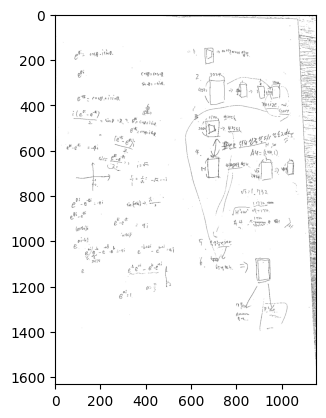

In [22]:
docu.img_spread(0,True)

In [23]:
docu.save_docu(name='docu1.jpg',path='/home/kim/rokey/ragular_cours/AI-course/my_playground')